# AtlanticRe — Axe 3 : Scoring Intelligent des Marchés Africains 2030
## Bloc 3 : Monte Carlo sur Intervalles Conformaux

**Principe** : Plutôt qu'un score déterministe (somme pondérée fixe), on exploite les incertitudes
conformal-prédictives calculées en Axe 2 (Step 9) pour simuler **N = 10 000 trajectoires** par pays.
Chaque tirage produit un score composite, ce qui donne une **distribution de scores** par pays.

**Sorties principales** :
- Score médian P50 (classement central robuste)
- Intervalles [P10 – P90] par pays (amplitude du risque/opportunité)
- Probabilité d'être dans le **Top 5 / Top 10** sur 33 pays
- Classement de consensus robuste (Borda count sur 1000 simulations bootstrap)
- Matrice des dépendances de classement entre paires de pays

---
**Pré-requis** : Avoir exécuté `axe2_atlanticre_predictions_2030.ipynb` dans le même dossier.
Les fichiers nécessaires sont :
- `predictions_2025_2030_AtlanticRe.csv` (df_pred exporté en Step 12)
- `score_attractivite_2030_AtlanticRe.csv` (df_score exporté en Step 12)
- Les 4 CSV sources originaux (pour reconstruire conformal_q si besoin)


## 0. Setup & Chargement

In [1]:
# ── INSTALLATION DES LIBRAIRIES ─────────────────────────────────────────────
# Décommenter si nécessaire
# !pip install scipy matplotlib seaborn pandas numpy scikit-learn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import truncnorm
import os

# Seed global — garantit la reproductibilité des simulations Monte Carlo
np.random.seed(42)

print("Librairies chargées ✓")
print(f"NumPy {np.__version__} | Pandas {pd.__version__}")

Librairies chargées ✓
NumPy 2.4.2 | Pandas 3.0.1


In [2]:
# ── CHEMINS DES FICHIERS ─────────────────────────────────────────────────────
BASE_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else '.'

PATH_PRED   = os.path.join(BASE_DIR, 'predictions_2025_2030_AtlanticRe.csv')
PATH_SCORE1 = os.path.join(BASE_DIR, 'score_attractivite_2030_AtlanticRe.csv')

# ── CHARGEMENT ───────────────────────────────────────────────────────────────
df_pred  = pd.read_csv(PATH_PRED)
assert not df_pred.empty, "Le fichier CSV chargé est vide — vérifier le chemin"
df_score1 = pd.read_csv(PATH_SCORE1, index_col=0)
assert not df_score1.empty, "Le fichier CSV chargé est vide — vérifier le chemin"

# Filtrer uniquement l'horizon 2030
df_2030 = df_pred[df_pred['Year'] == 2030].copy().reset_index(drop=True)

print(f"Prédictions chargées : {df_pred.shape[0]} lignes × {df_pred.shape[1]} colonnes")
print(f"Pays en 2030         : {df_2030['Pays'].nunique()}")
print(f"Colonnes 2030        : {list(df_2030.columns)}")
print(f"\nScore Axe 2 (référence) chargé : {df_score1.shape[0]} pays")

Prédictions chargées : 198 lignes × 38 colonnes
Pays en 2030         : 33
Colonnes 2030        : ['Pays', 'Year', 'Region', 'nv_penetration_pred', 'nv_penetration_lb80', 'nv_penetration_ub80', 'nv_penetration_lb95', 'nv_penetration_ub95', 'vie_penetration_pred', 'vie_penetration_lb80', 'vie_penetration_ub80', 'vie_penetration_lb95', 'vie_penetration_ub95', 'nv_sp_pred', 'nv_sp_lb80', 'nv_sp_ub80', 'nv_sp_lb95', 'nv_sp_ub95', 'gdpcap_pred', 'gdpcap_lb80', 'gdpcap_ub80', 'gdpcap_lb95', 'gdpcap_ub95', 'gdp_growth_pred', 'polstab_pred', 'polstab_lb80', 'polstab_ub80', 'regqual_pred', 'regqual_lb80', 'regqual_ub80', 'nv_primes_pred', 'nv_densite_pred', 'vie_primes_pred', 'vie_densite_pred', 'gdp_pred', 'population_pred', 'nv_croissance_pred', 'vie_croissance_pred']

Score Axe 2 (référence) chargé : 33 pays


## 1. Reconstruction des Intervalles Conformaux

Les intervalles `lb80 / ub80` dans `df_pred` ont été calculés avec `q80 × √h` (h = horizon).
On en extrait le `q80` par variable pour les simulations Monte Carlo.

In [3]:
# ── EXTRACTION DES q80 CONFORMAUX PAR VARIABLE ───────────────────────────────
# Les IC dans df_pred sont : pred ± q80 × √h  (h = horizon = 6 pour 2030)
# On récupère q80 = (ub80 - pred) / √6

H_2030 = 6.0  # horizon 2030 - 2024 = 6

VAR_IC = {
    'nv_penetration' : ('nv_penetration_pred',  'nv_penetration_lb80',  'nv_penetration_ub80',  True),
    'vie_penetration': ('vie_penetration_pred',  'vie_penetration_lb80', 'vie_penetration_ub80', True),
    'gdpcap'         : ('gdpcap_pred',           'gdpcap_lb80',          'gdpcap_ub80',          True),
    'nv_sp'          : ('nv_sp_pred',            'nv_sp_lb80',           'nv_sp_ub80',           False), # mean-reverting → h_factor=False
    'polstab'        : ('polstab_pred',          'polstab_lb80',         'polstab_ub80',          None),  # GPR natif
    'regqual'        : ('regqual_pred',          'regqual_lb80',         'regqual_ub80',          None),  # GPR natif
}

conformal_q_reconstructed = {}

for var, (col_pred, col_lb, col_ub, h_factor) in VAR_IC.items():
    half_ic = (df_2030[col_ub] - df_2030[col_pred]).median()
    if h_factor is True:
        q80 = half_ic / np.sqrt(H_2030)
    elif h_factor is False:
        q80 = half_ic  # pas de facteur √h
    else:
        q80 = half_ic  # GPR : l'IC est déjà absolu
    conformal_q_reconstructed[var] = float(q80)

print("=== q80 Conformaux Reconstruits (médiane sur 33 pays) ===")
for var, q in conformal_q_reconstructed.items():
    print(f"  {var:22s} : q80 = {q:.4f}")

=== q80 Conformaux Reconstruits (médiane sur 33 pays) ===
  nv_penetration         : q80 = 0.0779
  vie_penetration        : q80 = 0.1175
  gdpcap                 : q80 = 307.9009
  nv_sp                  : q80 = 8.7500
  polstab                : q80 = 0.1450
  regqual                : q80 = 0.0800


In [4]:
# ── SIGMA PAR PAYS (individuel, pas médian) ───────────────────────────────────
# Pour chaque pays et chaque variable, on calcule le σ individuel
# à partir des bornes lb80/ub80 stockées dans df_pred.
# σ_pays = (ub80 - lb80) / (2 × 1.282)  car P(|X| < 1.282σ) = 0.80

Z_80 = 1.2816  # quantile normal pour intervalle 80%

sigma_pays = {}  # {pays: {var: sigma}}

for _, row in df_2030.iterrows():
    pays = row['Pays']
    sigma_pays[pays] = {}
    for var, (col_pred, col_lb, col_ub, _) in VAR_IC.items():
        half = (row[col_ub] - row[col_lb]) / 2.0
        sigma_pays[pays][var] = max(float(half) / Z_80, 1e-6)

# Affichage de quelques pays représentatifs
print("=== Sigma individuel par pays (σ de la distribution de simulation) ===")
sample_pays = ['Maroc', 'Nigeria', 'Kenya', 'Côte d\'Ivoire', 'Tanzanie', 'Gabon']
print(f"{'Pays':<18}" + "".join(f"{v[:12]:>14}" for v in VAR_IC.keys()))
print("-" * 100)
for pays in sample_pays:
    if pays in sigma_pays:
        vals = [sigma_pays[pays].get(v, np.nan) for v in VAR_IC.keys()]
        row_str = f"{pays:<18}" + "".join(f"{v:>14.4f}" for v in vals)
        print(row_str)

=== Sigma individuel par pays (σ de la distribution de simulation) ===
Pays                nv_penetrati  vie_penetrat        gdpcap         nv_sp       polstab       regqual
----------------------------------------------------------------------------------------------------
Maroc                     0.1490        0.2247      588.4831        6.8274        0.0328        0.0683
Nigeria                   0.1489        0.2246      588.4831        6.8274        0.0839        0.1104
Kenya                     0.1490        0.2247      588.5222        6.8313        0.0913        0.0749
Côte d'Ivoire             0.1489        0.2246      588.4831        6.8313        0.1486        0.0769
Tanzanie                  0.1490        0.2247      588.5222        6.8313        0.1073        0.0519
Gabon                     0.1490        0.2246      588.4831        6.8274        0.1588        0.0780


## 2. Paramétrage du Modèle de Scoring Monte Carlo

In [5]:
# ── PARAMÈTRES GLOBAUX DE LA SIMULATION ──────────────────────────────────────

N_SIMULATIONS = 10_000   # Nombre de tirages Monte Carlo
RANDOM_SEED   = 42  # Seed défini globalement en cellule 0 — ne pas redéfinir ici

# ── BORNES PHYSIQUES PAR VARIABLE (contraintes métier) ───────────────────────
BOUNDS = {
    'nv_penetration' : (0.01,  5.0),
    'vie_penetration': (0.001, 10.0),
    'gdpcap'         : (100.0, None),
    'nv_sp'          : (5.0,   95.0),
    'polstab'        : (-2.5,  2.5),
    'regqual'        : (-2.5,  2.5),
}

# ── POIDS DU SCORE COMPOSITE ─────────────────────────────────────────────────
# Mêmes poids que l'Axe 2 (Step 11) pour comparabilité.
# Le Bloc 1 (PCA) les remplacera par des poids appris.
SCORE_WEIGHTS = {
    'nv_penetration' : 0.30,   # + taille du marché NV
    'nv_sp'          : 0.25,   # − inversé (S/P bas = rentable)
    'gdpcap'         : 0.20,   # + richesse individuelle
    'polstab'        : 0.12,   # + stabilité opérationnelle
    'regqual'        : 0.08,   # + cadre réglementaire
    'vie_penetration': 0.05,   # + diversification Vie
}

# Variables à MINIMISER (score inversé)
VARS_INVERTED = {'nv_sp'}  # S/P bas = bon

PAYS_33 = sorted(df_2030['Pays'].unique())
N_PAYS  = len(PAYS_33)

print(f"Simulation Monte Carlo : N = {N_SIMULATIONS:,} tirages × {N_PAYS} pays")
print(f"Variables scorées      : {list(SCORE_WEIGHTS.keys())}")
print(f"Variable(s) inversée(s): {VARS_INVERTED}")
print(f"\nPoids :")
for v, w in SCORE_WEIGHTS.items():
    print(f"  {v:22s} : {w*100:.0f}%")

Simulation Monte Carlo : N = 10,000 tirages × 33 pays
Variables scorées      : ['nv_penetration', 'nv_sp', 'gdpcap', 'polstab', 'regqual', 'vie_penetration']
Variable(s) inversée(s): {'nv_sp'}

Poids :
  nv_penetration         : 30%
  nv_sp                  : 25%
  gdpcap                 : 20%
  polstab                : 12%
  regqual                : 8%
  vie_penetration        : 5%


## 3. Simulation Monte Carlo Principale

Pour chaque tirage `k = 1..N` :
1. Tirer `x_k(pays, var) ~ TruncNormal(μ=pred, σ=σ_pays_var, bornes physiques)`
2. Normaliser en [0,1] sur les 33 pays (min-max de ce tirage)
3. Inverser la variable S/P
4. Calculer le score composite pondéré
5. Stocker le vecteur de scores (33 pays) et le rang de chaque pays

In [6]:
# ── CONSTRUCTION DE LA MATRICE DE VALEURS CENTRALES ──────────────────────────
# Shape : (N_PAYS, N_VARS)

VARS_ORDER = list(SCORE_WEIGHTS.keys())
COL_MAP    = {
    'nv_penetration' : 'nv_penetration_pred',
    'vie_penetration': 'vie_penetration_pred',
    'gdpcap'         : 'gdpcap_pred',
    'nv_sp'          : 'nv_sp_pred',
    'polstab'        : 'polstab_pred',
    'regqual'        : 'regqual_pred',
}

df_2030_idx = df_2030.set_index('Pays')

mu_matrix    = np.zeros((N_PAYS, len(VARS_ORDER)))  # valeurs centrales
sigma_matrix = np.zeros((N_PAYS, len(VARS_ORDER)))  # écarts-types

for j, var in enumerate(VARS_ORDER):
    col_pred = COL_MAP[var]
    for i, pays in enumerate(PAYS_33):
        mu_matrix[i, j]    = float(df_2030_idx.loc[pays, col_pred])
        sigma_matrix[i, j] = sigma_pays[pays].get(var, 1e-6)

print(f"Matrice μ    : {mu_matrix.shape} (pays × variables)")
print(f"Matrice σ    : {sigma_matrix.shape}")
print(f"\nStatistiques des σ :")
for j, var in enumerate(VARS_ORDER):
    s = sigma_matrix[:, j]
    print(f"  {var:22s} : σ_min={s.min():.4f}  σ_med={np.median(s):.4f}  σ_max={s.max():.4f}")

Matrice μ    : (33, 6) (pays × variables)
Matrice σ    : (33, 6)

Statistiques des σ :
  nv_penetration         : σ_min=0.1157  σ_med=0.1489  σ_max=0.1490
  nv_sp                  : σ_min=6.8274  σ_med=6.8313  σ_max=6.8313
  gdpcap                 : σ_min=391.6979  σ_med=588.4831  σ_max=588.5222
  polstab                : σ_min=0.0328  σ_med=0.1131  σ_max=0.2497
  regqual                : σ_min=0.0293  σ_med=0.0624  σ_max=0.1237
  vie_penetration        : σ_min=0.1123  σ_med=0.2247  σ_max=0.2247


In [7]:
# ── SIMULATION MONTE CARLO ───────────────────────────────────────────────────
# all_scores[k, i] = score du pays i au tirage k  (avant normalisation finale)
# all_ranks[k, i]  = rang du pays i au tirage k   (1 = meilleur)

weights_arr = np.array([SCORE_WEIGHTS[v] for v in VARS_ORDER])  # (N_VARS,)

all_scores = np.zeros((N_SIMULATIONS, N_PAYS))
all_ranks  = np.zeros((N_SIMULATIONS, N_PAYS), dtype=int)

# Pré-calcul des bornes normalisées pour truncnorm
# truncnorm requiert a=(lb-mu)/sigma, b=(ub-mu)/sigma
def draw_truncnorm_matrix(mu, sigma, bounds_list, n_draw):
    """
    Tire n_draw échantillons pour la matrice (N_PAYS, N_VARS).
    Retourne array (n_draw, N_PAYS, N_VARS).
    """
    n_pays, n_vars = mu.shape
    samples = np.zeros((n_draw, n_pays, n_vars))
    for j in range(n_vars):
        lb, ub = bounds_list[j]
        mu_j  = mu[:, j]     # (N_PAYS,)
        sig_j = sigma[:, j]  # (N_PAYS,)
        a_j = ((lb if lb is not None else -np.inf) - mu_j) / sig_j
        b_j = ((ub if ub is not None else  np.inf) - mu_j) / sig_j
        for i in range(n_pays):
            samples[:, i, j] = truncnorm.rvs(
                a=a_j[i], b=b_j[i],
                loc=mu_j[i], scale=sig_j[i],
                size=n_draw, random_state=RANDOM_SEED + i*31 + j*7
            )
    return samples

bounds_list = [BOUNDS[v] for v in VARS_ORDER]

print("Génération des tirages Monte Carlo...")
# Shape : (N_SIMULATIONS, N_PAYS, N_VARS)
samples_3d = draw_truncnorm_matrix(mu_matrix, sigma_matrix, bounds_list, N_SIMULATIONS)
print(f"Tirages générés : {samples_3d.shape}  ✓")

print("Calcul des scores et rangs...")
for k in range(N_SIMULATIONS):
    X = samples_3d[k]  # (N_PAYS, N_VARS)
    
    # Min-max normalisation [0,1] sur les 33 pays pour ce tirage
    X_min  = X.min(axis=0, keepdims=True)
    X_max  = X.max(axis=0, keepdims=True)
    X_norm = (X - X_min) / (X_max - X_min + 1e-12)  # (N_PAYS, N_VARS)
    
    # Inversion des variables à minimiser (S/P)
    for j, var in enumerate(VARS_ORDER):
        if var in VARS_INVERTED:
            X_norm[:, j] = 1.0 - X_norm[:, j]
    
    # Score composite
    scores = X_norm @ weights_arr  # (N_PAYS,)
    all_scores[k] = scores
    
    # Rangs (1 = meilleur score)
    # argsort décroissant → rang
    order = np.argsort(-scores)  # indices triés du meilleur au pire
    ranks = np.empty(N_PAYS, dtype=int)
    ranks[order] = np.arange(1, N_PAYS + 1)
    all_ranks[k] = ranks

print(f"Simulation terminée ✓  ({N_SIMULATIONS:,} tirages × {N_PAYS} pays)")

Génération des tirages Monte Carlo...
Tirages générés : (10000, 33, 6)  ✓
Calcul des scores et rangs...
Simulation terminée ✓  (10,000 tirages × 33 pays)


## 4. Construction des Métriques de Scoring Robuste

In [8]:
# ── PERCENTILES DES SCORES & RANGS ────────────────────────────────────────────
# Scores normalisés en [0, 100] pour chaque percentile

# Normaliser all_scores en [0, 100] par tirage
all_scores_100 = all_scores * 100.0  # déjà en [0,1] car poids somment à 1

PERCENTILES = [5, 10, 25, 50, 75, 90, 95]

results = []
for i, pays in enumerate(PAYS_33):
    scores_i = all_scores_100[:, i]
    ranks_i  = all_ranks[:, i]
    
    pct_scores = np.percentile(scores_i, PERCENTILES)
    pct_ranks  = np.percentile(ranks_i,  PERCENTILES)
    
    # Probabilités d'être dans le Top N
    prob_top5  = float(np.mean(ranks_i <= 5)  * 100)
    prob_top10 = float(np.mean(ranks_i <= 10) * 100)
    prob_top15 = float(np.mean(ranks_i <= 15) * 100)
    
    # Rang médian
    rank_median = float(np.median(ranks_i))
    rank_mean   = float(np.mean(ranks_i))
    rank_std    = float(np.std(ranks_i))
    
    # Score moyen ± std
    score_mean = float(np.mean(scores_i))
    score_std  = float(np.std(scores_i))
    
    # Amplitude de l'incertitude (P90 - P10)
    uncertainty_range = float(pct_scores[PERCENTILES.index(90)] - pct_scores[PERCENTILES.index(10)])
    
    row = {
        'Pays'              : pays,
        'Region'            : df_2030_idx.loc[pays, 'Region'],
        'score_P05'         : round(pct_scores[0], 2),
        'score_P10'         : round(pct_scores[1], 2),
        'score_P25'         : round(pct_scores[2], 2),
        'score_P50'         : round(pct_scores[3], 2),
        'score_P75'         : round(pct_scores[4], 2),
        'score_P90'         : round(pct_scores[5], 2),
        'score_P95'         : round(pct_scores[6], 2),
        'score_mean'        : round(score_mean, 2),
        'score_std'         : round(score_std, 2),
        'uncertainty_range' : round(uncertainty_range, 2),
        'rank_median'       : int(round(rank_median)),
        'rank_mean'         : round(rank_mean, 1),
        'rank_std'          : round(rank_std, 1),
        'prob_top5_pct'     : round(prob_top5, 1),
        'prob_top10_pct'    : round(prob_top10, 1),
        'prob_top15_pct'    : round(prob_top15, 1),
    }
    results.append(row)

df_mc = pd.DataFrame(results).sort_values('score_P50', ascending=False).reset_index(drop=True)
df_mc.index += 1  # rang 1-based
df_mc['rang_P50'] = df_mc.index

# Ajouter le score Axe 2 original pour comparaison
df_mc = df_mc.merge(
    df_score1[['Pays','score_attractivite_100']].rename(columns={'score_attractivite_100':'score_axe2'}),
    on='Pays', how='left'
)
df_mc['delta_rang_vs_axe2'] = df_mc['rang_P50'] - df_mc['Pays'].map(
    df_score1.reset_index().set_index('Pays')['index'] if 'index' in df_score1.reset_index().columns
    else df_score1.reset_index().rename(columns={'index':'rang_axe2'}).set_index('Pays')['rang_axe2']
)

print("=== CLASSEMENT MONTE CARLO — Score P50 (sur 33 pays) ===")
cols_display = ['Pays','Region','score_P10','score_P50','score_P90',
                'uncertainty_range','rank_median','prob_top5_pct','prob_top10_pct','score_axe2']
print(df_mc[cols_display].to_string())

=== CLASSEMENT MONTE CARLO — Score P50 (sur 33 pays) ===
             Pays              Region  score_P10  score_P50  score_P90  uncertainty_range  rank_median  prob_top5_pct  prob_top10_pct  score_axe2
0         Namibie    Afrique Australe      72.33      77.45      80.85               8.52            1          100.0           100.0       100.0
1         Maurice    Afrique Australe      69.02      74.40      80.05              11.03            2          100.0           100.0        92.8
2        Cap-Vert  Afrique de l'Ouest      52.30      57.97      63.77              11.48            3           98.2           100.0        73.5
3        Botswana    Afrique Australe      49.18      55.00      60.51              11.33            4           92.1            99.9        69.3
4           Maroc     Afrique du Nord      46.00      49.95      54.35               8.36            5           60.2            99.9        61.4
5          Zambie    Afrique Australe      40.56      46.14      51

## 5. Classement de Consensus Robuste (Borda Count Bootstrap)

In [9]:
# ── BORDA COUNT SUR 1000 BOOTSTRAP ───────────────────────────────────────────
# Pour chaque bootstrap b (tirage de 1000 simulations parmi 10 000) :
#   - Calculer le rang médian de chaque pays
#   - Attribuer les points Borda : N_PAYS - rang + 1  (33 pts au 1er, 1 pt au dernier)
# Score Borda final = moyenne des points Borda sur B bootstraps

N_BOOTSTRAP = 1000
SAMPLE_SIZE = 1000

borda_points = np.zeros(N_PAYS)  # score Borda cumulé par pays

rng = np.random.default_rng(RANDOM_SEED)

for b in range(N_BOOTSTRAP):
    # Tirer SAMPLE_SIZE indices parmi les N_SIMULATIONS tirages
    idx = rng.integers(0, N_SIMULATIONS, size=SAMPLE_SIZE)
    ranks_b = all_ranks[idx]  # (SAMPLE_SIZE, N_PAYS)
    
    # Rang médian de chaque pays dans ce bootstrap
    median_ranks_b = np.median(ranks_b, axis=0)  # (N_PAYS,)
    
    # Ordre de classement (du meilleur rang au pire)
    order_b = np.argsort(median_ranks_b)
    
    # Points Borda
    borda_b = np.zeros(N_PAYS)
    for rank_pos, pays_idx in enumerate(order_b):
        borda_b[pays_idx] = N_PAYS - rank_pos  # N_PAYS pts au meilleur, 1 pt au pire
    
    borda_points += borda_b

borda_mean = borda_points / N_BOOTSTRAP

# Créer le DataFrame du classement Borda
df_borda = pd.DataFrame({'Pays': PAYS_33, 'borda_score': borda_mean})
df_borda = df_borda.sort_values('borda_score', ascending=False).reset_index(drop=True)
df_borda.index += 1
df_borda['rang_borda'] = df_borda.index

# Fusion avec df_mc
df_mc = df_mc.merge(df_borda[['Pays','borda_score','rang_borda']], on='Pays', how='left')

print("=== CLASSEMENT BORDA BOOTSTRAP (consensus robuste) ===")
print(df_borda.to_string())

=== CLASSEMENT BORDA BOOTSTRAP (consensus robuste) ===
             Pays  borda_score  rang_borda
1         Namibie       33.000           1
2         Maurice       32.000           2
3        Cap-Vert       31.000           3
4        Botswana       30.000           4
5           Maroc       29.000           5
6          Zambie       28.000           6
7         Tunisie       26.738           7
8           Congo       26.253           8
9           Gabon       25.009           9
10        Sénégal       24.000          10
11        Algérie       22.983          11
12          Ghana       22.017          12
13         Angola       21.000          13
14       Tanzanie       20.000          14
15  Côte d'Ivoire       18.999          15
16          Bénin       18.001          16
17         Égypte       17.000          17
18     Madagascar       15.936          18
19       Cameroun       14.867          19
20     Mozambique       14.197          20
21          Kenya       13.000          21

## 6. Export du Scoring Final

In [10]:
# ── EXPORT CSV ───────────────────────────────────────────────────────────────
OUTPUT_SCORING = 'scoring_mc_2030_AtlanticRe.csv'

df_mc_export = df_mc[[
    'Pays','Region','rang_P50','rang_borda',
    'score_P05','score_P10','score_P25','score_P50',
    'score_P75','score_P90','score_P95',
    'score_mean','score_std','uncertainty_range',
    'rank_median','rank_mean','rank_std',
    'prob_top5_pct','prob_top10_pct','prob_top15_pct',
    'borda_score','score_axe2'
]].copy()

df_mc_export.to_csv(OUTPUT_SCORING, index=False)
print(f"Scoring exporté → {OUTPUT_SCORING}")
print(f"Shape : {df_mc_export.shape}")
print("\n=== TOP 15 — Vue synthétique ===")
print(df_mc_export.head(15)[[
    'Pays','Region','rang_P50','rang_borda',
    'score_P10','score_P50','score_P90',
    'uncertainty_range','prob_top5_pct','prob_top10_pct'
]].to_string())

Scoring exporté → scoring_mc_2030_AtlanticRe.csv
Shape : (33, 22)

=== TOP 15 — Vue synthétique ===
             Pays              Region  rang_P50  rang_borda  score_P10  score_P50  score_P90  uncertainty_range  prob_top5_pct  prob_top10_pct
0         Namibie    Afrique Australe         1           1      72.33      77.45      80.85               8.52          100.0           100.0
1         Maurice    Afrique Australe         2           2      69.02      74.40      80.05              11.03          100.0           100.0
2        Cap-Vert  Afrique de l'Ouest         3           3      52.30      57.97      63.77              11.48           98.2           100.0
3        Botswana    Afrique Australe         4           4      49.18      55.00      60.51              11.33           92.1            99.9
4           Maroc     Afrique du Nord         5           5      46.00      49.95      54.35               8.36           60.2            99.9
5          Zambie    Afrique Australe     

## 7. Visualisations

### 7.1 — Classement P50 avec intervalles [P10–P90]

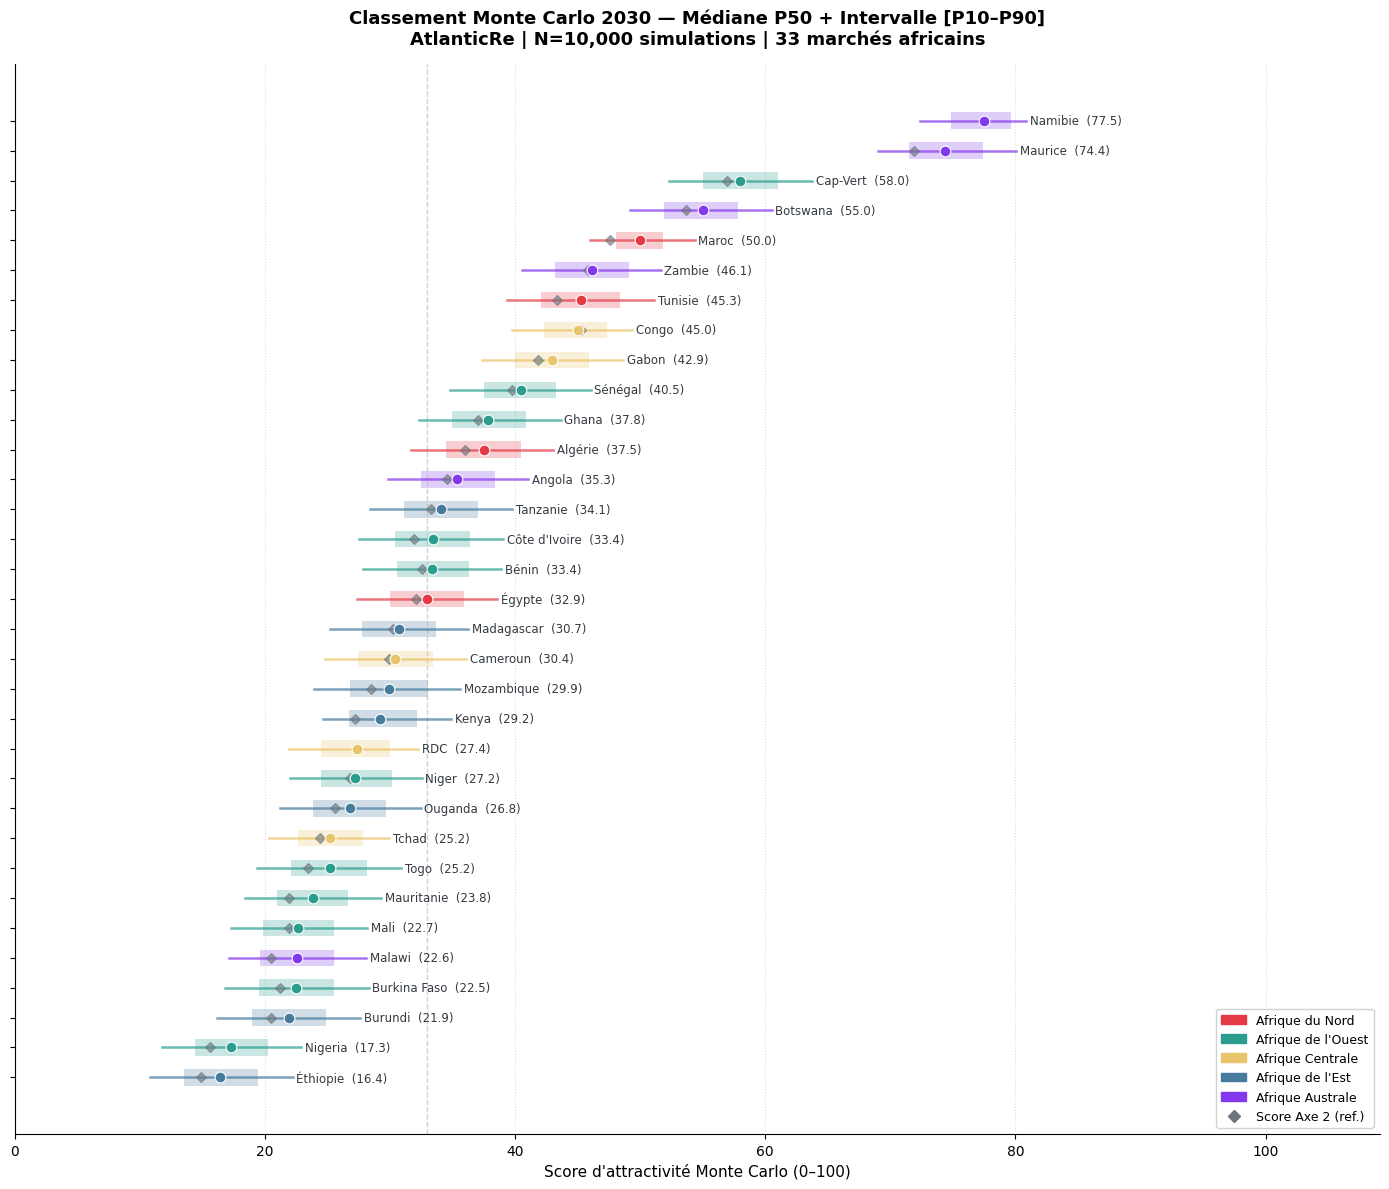

Graphique sauvegardé : mc_classement_p50_ic.png


In [11]:
# ── VIZ 1 : CLASSEMENT P50 AVEC IC [P10–P90] ─────────────────────────────────

REGION_COLORS = {
    'Afrique du Nord'   : '#e63946',
    "Afrique de l'Ouest": '#2a9d8f',
    'Afrique Centrale'  : '#e9c46a',
    "Afrique de l'Est"  : '#457b9d',
    'Afrique Australe'  : '#8338ec',
}

fig, ax = plt.subplots(figsize=(14, 12))

# Trier par P50 décroissant (déjà fait dans df_mc)
df_plot = df_mc.sort_values('score_P50', ascending=True)  # ascending pour barh

y_pos = np.arange(len(df_plot))

for idx, (_, row) in enumerate(df_plot.iterrows()):
    color = REGION_COLORS.get(row['Region'], '#adb5bd')
    
    # Barre P25–P75 (épaisse, transparente)
    ax.barh(idx, row['score_P75'] - row['score_P25'],
            left=row['score_P25'], height=0.55,
            color=color, alpha=0.25, zorder=2)
    
    # Ligne P10–P90
    ax.plot([row['score_P10'], row['score_P90']], [idx, idx],
            color=color, linewidth=1.8, alpha=0.7, zorder=3)
    
    # Marqueur P50
    ax.scatter(row['score_P50'], idx, color=color, s=60,
               zorder=5, edgecolors='white', linewidths=0.8)
    
    # Score Axe 2 (losange gris)
    if not pd.isna(row.get('score_axe2')):
        # Normaliser score_axe2 (en /100 puis × max_P50/100)
        ax.scatter(row['score_axe2'] * df_mc['score_P50'].max() / 100.0,
                   idx, marker='D', color='#6c757d',
                   s=25, zorder=4, alpha=0.6)
    
    # Label
    ax.text(row['score_P90'] + 0.3, idx,
            f"{row['Pays']}  ({row['score_P50']:.1f})",
            va='center', fontsize=8.5, color='#343a40')

# Légende régions
handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
handles.append(plt.Line2D([0],[0], marker='D', color='#6c757d',
                           markersize=6, linestyle='None', label='Score Axe 2 (ref.)'))
ax.legend(handles=handles, loc='lower right', fontsize=9, framealpha=0.9)

ax.set_yticks(y_pos)
ax.set_yticklabels([''] * len(df_plot))  # labels déjà en annotation
ax.set_xlabel('Score d\'attractivité Monte Carlo (0–100)', fontsize=11)
ax.set_title(
    f'Classement Monte Carlo 2030 — Médiane P50 + Intervalle [P10–P90]\n'
    f'AtlanticRe | N={N_SIMULATIONS:,} simulations | 33 marchés africains',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlim(0, df_mc['score_P90'].max() * 1.35)
ax.axvline(df_mc['score_P50'].median(), color='#adb5bd',
           linestyle='--', linewidth=1, alpha=0.6, label='Médiane globale')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('mc_classement_p50_ic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : mc_classement_p50_ic.png")

### 7.2 — Carte Risque/Opportunité : Score P50 vs Incertitude

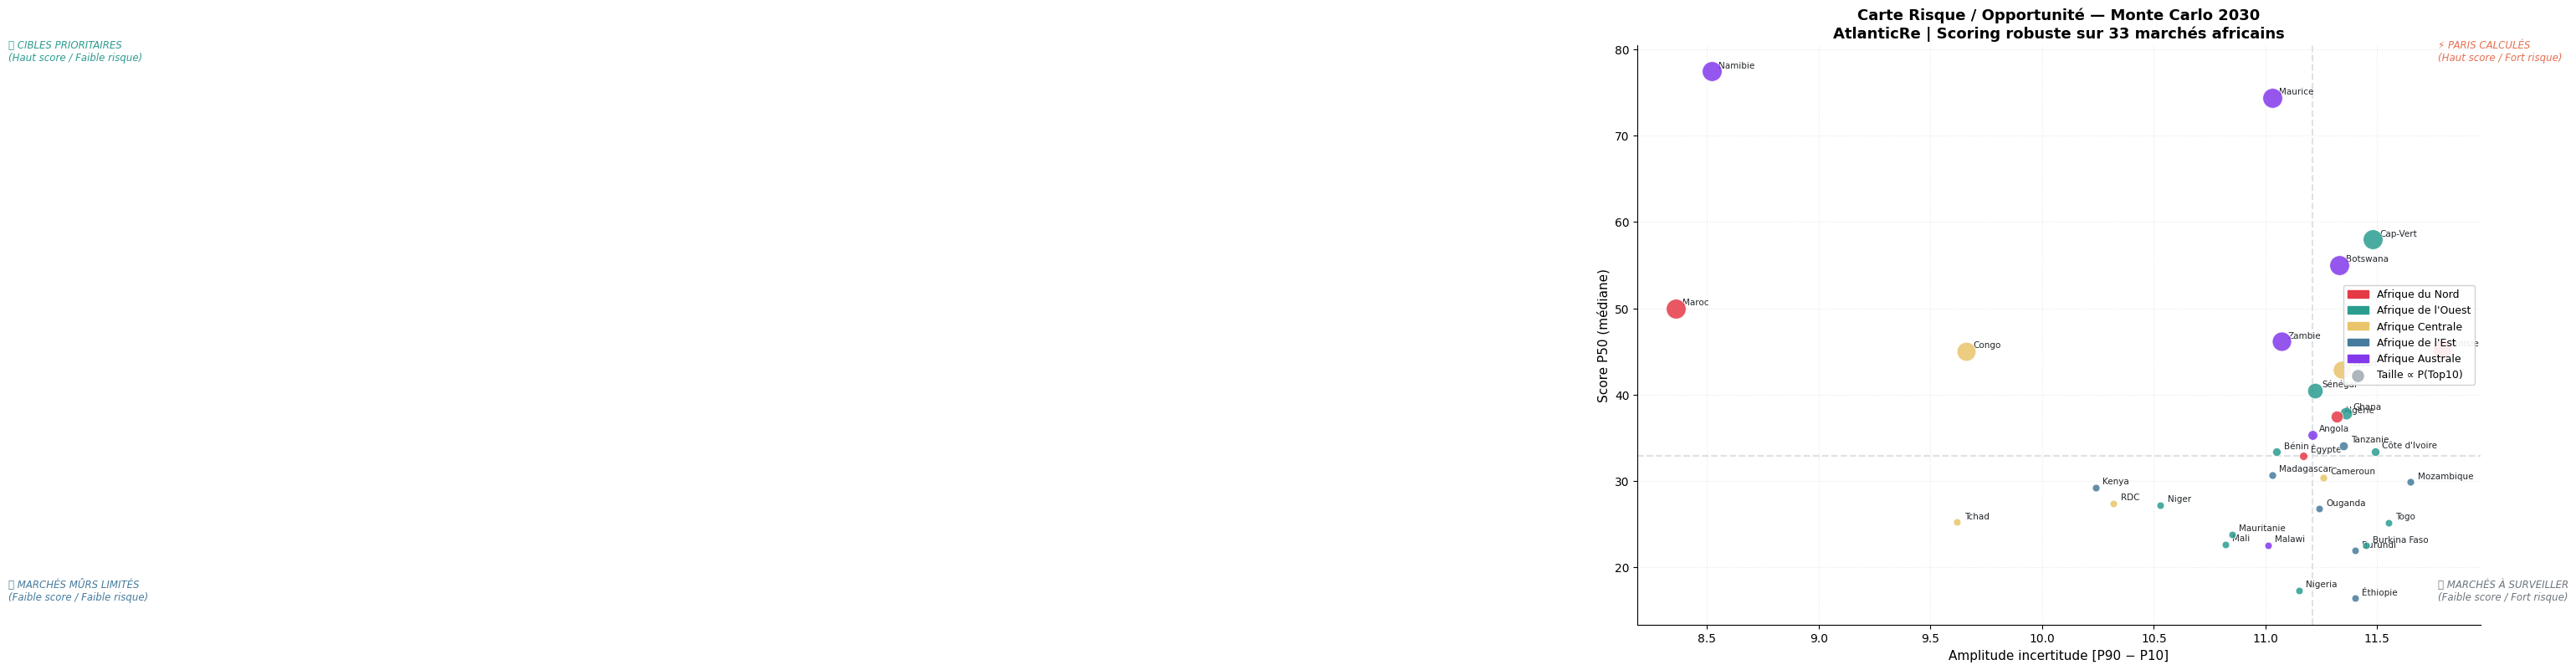

Graphique sauvegardé : mc_carte_risque_opportunite.png


In [12]:
# ── VIZ 2 : SCATTER — SCORE P50 vs INCERTITUDE (P90-P10) ─────────────────────
# Quadrants :
#   Q1 (haut-gauche)  : Score élevé, faible incertitude → CIBLES PRIORITAIRES
#   Q2 (haut-droit)   : Score élevé, forte incertitude → PARIS CALCULÉS
#   Q3 (bas-gauche)   : Score faible, faible incertitude → MARCHÉS STABLES MAIS LIMITÉS
#   Q4 (bas-droit)    : Score faible, forte incertitude → À ÉVITER

fig, ax = plt.subplots(figsize=(13, 9))

# Médianes pour les quadrants
med_score = df_mc['score_P50'].median()
med_uncert = df_mc['uncertainty_range'].median()

# Quadrants
ax.axvline(med_uncert, color='#dee2e6', linestyle='--', linewidth=1.5)
ax.axhline(med_score,  color='#dee2e6', linestyle='--', linewidth=1.5)

# Labels quadrants
x_max = df_mc['uncertainty_range'].max() * 1.1
y_max = df_mc['score_P50'].max() * 1.08
y_min = df_mc['score_P50'].min() * 0.92

ax.text(med_uncert * 0.08, y_max * 0.97,
        '🎯 CIBLES PRIORITAIRES\n(Haut score / Faible risque)',
        fontsize=8.5, color='#2a9d8f', style='italic', va='top')
ax.text(med_uncert * 1.05, y_max * 0.97,
        '⚡ PARIS CALCULÉS\n(Haut score / Fort risque)',
        fontsize=8.5, color='#e76f51', style='italic', va='top')
ax.text(med_uncert * 0.08, y_min * 1.05,
        '⏸ MARCHÉS MÛRS LIMITÉS\n(Faible score / Faible risque)',
        fontsize=8.5, color='#457b9d', style='italic', va='bottom')
ax.text(med_uncert * 1.05, y_min * 1.05,
        '🚫 MARCHÉS À SURVEILLER\n(Faible score / Fort risque)',
        fontsize=8.5, color='#6c757d', style='italic', va='bottom')

# Points
for _, row in df_mc.iterrows():
    color = REGION_COLORS.get(row['Region'], '#adb5bd')
    size  = 40 + row['prob_top10_pct'] * 2.5  # taille ∝ proba Top10
    ax.scatter(row['uncertainty_range'], row['score_P50'],
               color=color, s=size, alpha=0.85,
               edgecolors='white', linewidths=0.6, zorder=4)
    ax.annotate(
        row['Pays'],
        (row['uncertainty_range'], row['score_P50']),
        textcoords='offset points', xytext=(6, 3),
        fontsize=7.5, color='#212529'
    )

# Légende
handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
handles.append(
    plt.scatter([], [], s=90, color='#adb5bd',
                label='Taille ∝ P(Top10)')
)
ax.legend(handles=handles, fontsize=9, loc='center right', framealpha=0.9)

ax.set_xlabel('Amplitude incertitude [P90 − P10]', fontsize=11)
ax.set_ylabel('Score P50 (médiane)', fontsize=11)
ax.set_title(
    'Carte Risque / Opportunité — Monte Carlo 2030\n'
    'AtlanticRe | Scoring robuste sur 33 marchés africains',
    fontsize=13, fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig('mc_carte_risque_opportunite.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : mc_carte_risque_opportunite.png")

### 7.3 — Distributions des Scores : Top 10 Pays

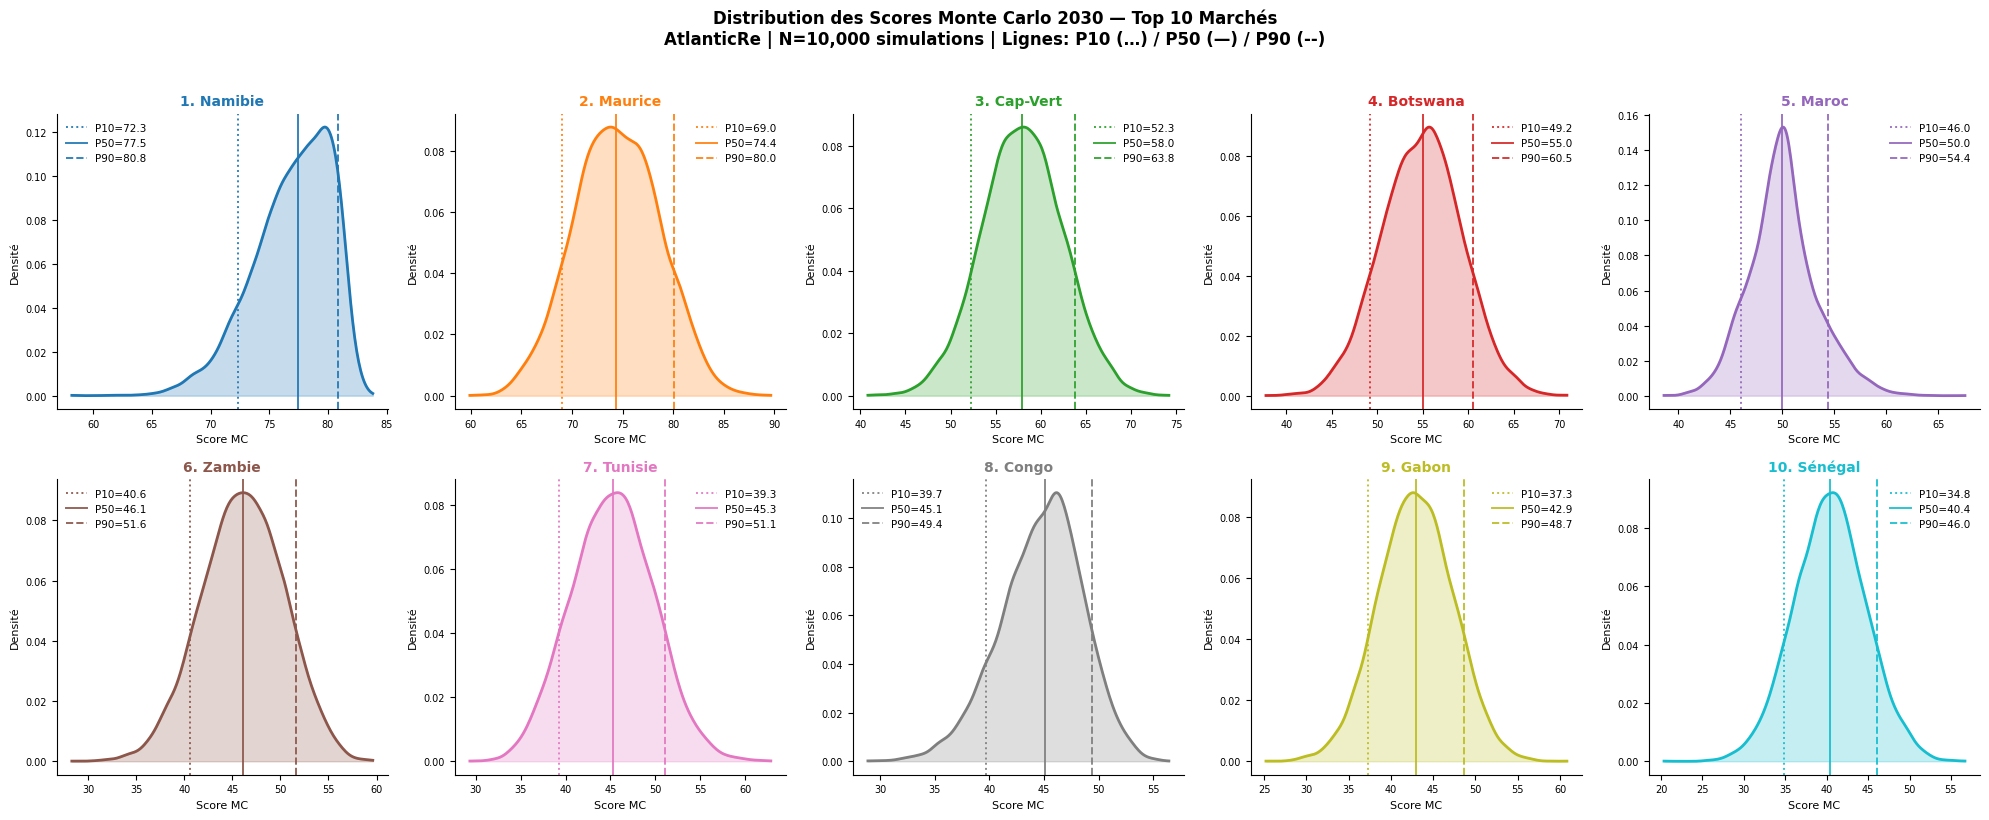

Graphique sauvegardé : mc_distributions_top10.png


In [13]:
# ── VIZ 3 : DISTRIBUTIONS SCORES — TOP 10 ─────────────────────────────────────

top10_pays = df_mc.sort_values('score_P50', ascending=False)['Pays'].head(10).tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=False)
axes = axes.flatten()

colors_top10 = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, pays in enumerate(top10_pays):
    ax = axes[idx]
    i  = PAYS_33.index(pays)
    scores_i = all_scores_100[:, i]
    
    # KDE
    kde = stats.gaussian_kde(scores_i, bw_method='scott')
    x_range = np.linspace(scores_i.min(), scores_i.max(), 300)
    y_kde   = kde(x_range)
    
    ax.fill_between(x_range, y_kde, alpha=0.25, color=colors_top10[idx])
    ax.plot(x_range, y_kde, color=colors_top10[idx], linewidth=2)
    
    # Marqueurs P10, P50, P90
    for pct, ls, lbl in [(10,':', 'P10'), (50,'-', 'P50'), (90,'--','P90')]:
        v = np.percentile(scores_i, pct)
        ax.axvline(v, linestyle=ls, color=colors_top10[idx],
                   linewidth=1.4, alpha=0.9,
                   label=f'{lbl}={v:.1f}')
    
    ax.set_title(f'{idx+1}. {pays}', fontsize=10, fontweight='bold',
                 color=colors_top10[idx])
    ax.legend(fontsize=7.5, frameon=False)
    ax.set_xlabel('Score MC', fontsize=8)
    ax.set_ylabel('Densité', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=7)

fig.suptitle(
    'Distribution des Scores Monte Carlo 2030 — Top 10 Marchés\n'
    f'AtlanticRe | N={N_SIMULATIONS:,} simulations | Lignes: P10 (…) / P50 (—) / P90 (--)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('mc_distributions_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : mc_distributions_top10.png")

### 7.4 — Probabilité d'être dans le Top 5 / Top 10 / Top 15

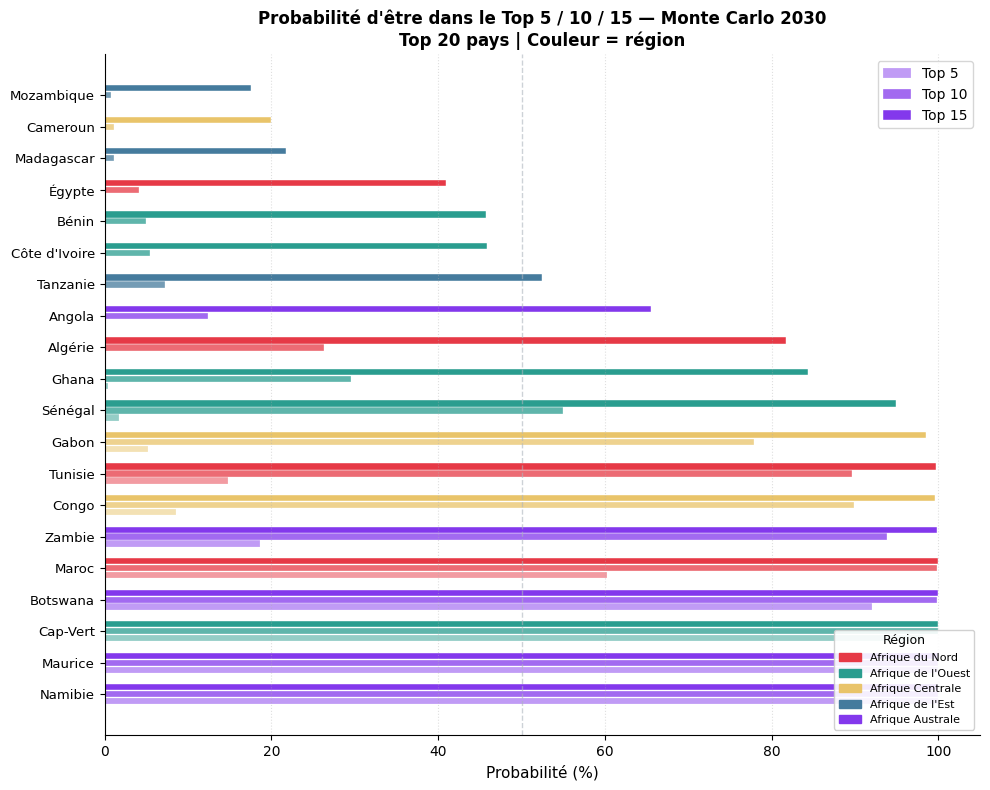

Graphique sauvegardé : mc_proba_topN.png


In [14]:
# ── VIZ 4 : HEATMAP PROBABILITÉS TOP N ───────────────────────────────────────

df_plot_prob = df_mc.sort_values('prob_top10_pct', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))

x_pos = np.arange(3)
labels_top = ['Top 5', 'Top 10', 'Top 15']
cols_prob   = ['prob_top5_pct', 'prob_top10_pct', 'prob_top15_pct']

bar_width = 0.22
y_pos = np.arange(len(df_plot_prob))

for k, (col, label) in enumerate(zip(cols_prob, labels_top)):
    offsets = y_pos + (k - 1) * bar_width
    colors_bar = [
        REGION_COLORS.get(row['Region'], '#adb5bd')
        for _, row in df_plot_prob.iterrows()
    ]
    alphas = [0.5, 0.75, 1.0][k]
    ax.barh(offsets, df_plot_prob[col].values,
            height=bar_width * 0.9,
            color=colors_bar, alpha=alphas,
            label=label, edgecolor='white', linewidth=0.3)

ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f"{row['Pays']}" for _, row in df_plot_prob.iterrows()],
    fontsize=9.5
)
ax.set_xlabel('Probabilité (%)', fontsize=11)
ax.set_title(
    'Probabilité d\'être dans le Top 5 / 10 / 15 — Monte Carlo 2030\n'
    'Top 20 pays | Couleur = région',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.axvline(50, color='#adb5bd', linestyle='--', linewidth=1, alpha=0.6)

# Légende région
region_handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax2 = ax.twinx()
ax2.axis('off')
ax2.legend(handles=region_handles, fontsize=8, loc='lower right',
           title='Région', title_fontsize=9, framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.4)
ax.set_xlim(0, 105)

plt.tight_layout()
plt.savefig('mc_proba_topN.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : mc_proba_topN.png")

### 7.5 — Matrice de Stabilité des Classements Pairés

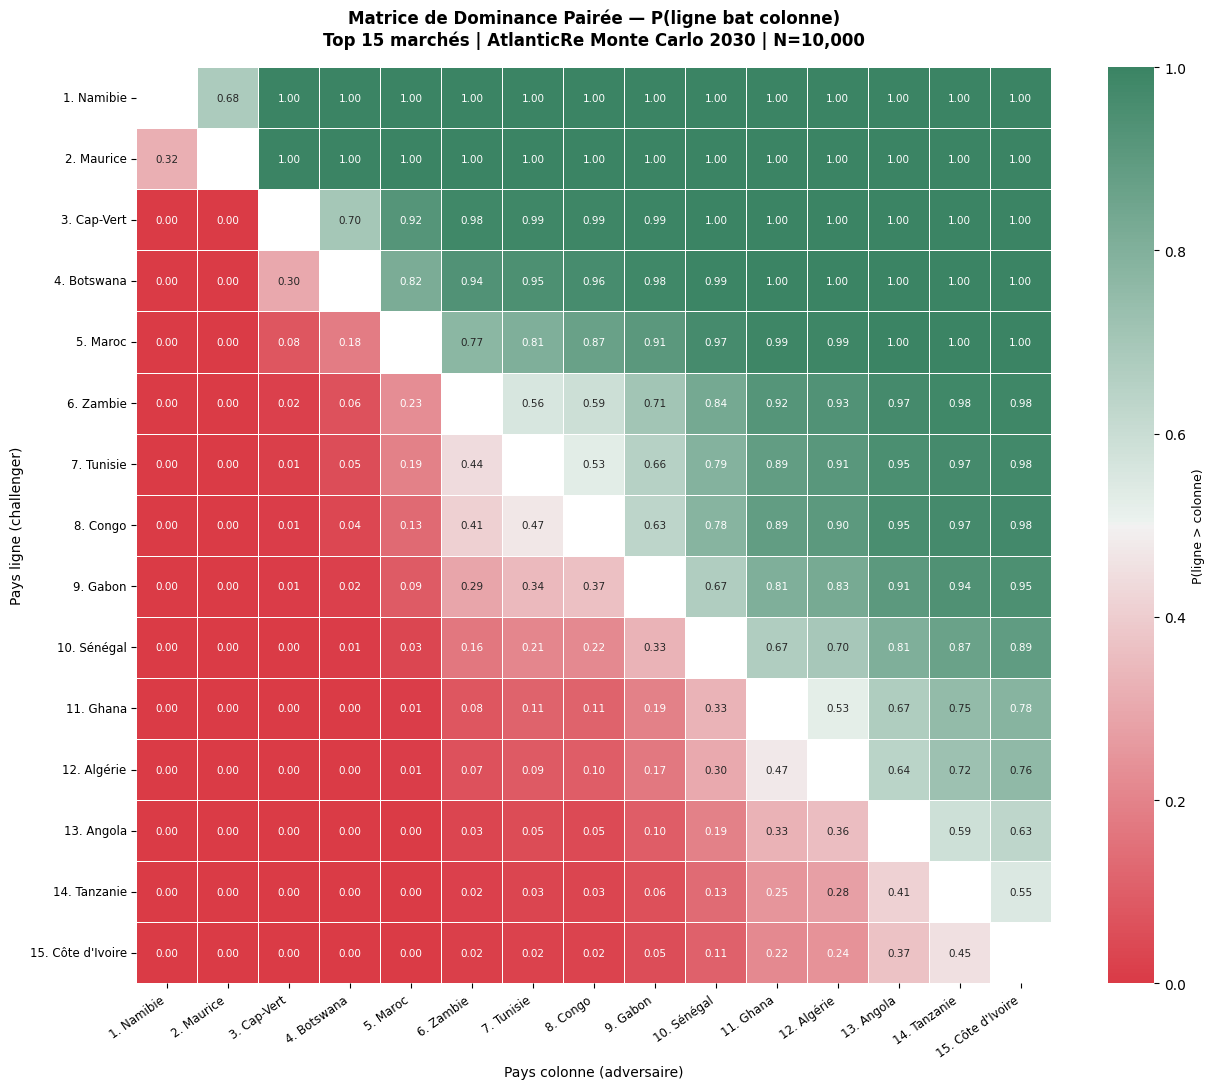

Graphique sauvegardé : mc_matrice_dominance.png


In [15]:
# ── VIZ 5 : MATRICE PAIRÉE — P(pays_i bat pays_j) ────────────────────────────
# win_matrix[i, j] = fraction des simulations où pays_i est mieux classé que pays_j
# Limité au Top 15 pour lisibilité

top15_pays = df_mc.sort_values('score_P50', ascending=False)['Pays'].head(15).tolist()
top15_idx  = [PAYS_33.index(p) for p in top15_pays]

N_TOP = len(top15_pays)
win_matrix = np.zeros((N_TOP, N_TOP))

# Sous-ensemble des scores : (N_SIMULATIONS, N_TOP)
scores_top = all_scores[:, top15_idx]  # (N_SIMULATIONS, N_TOP)

for i in range(N_TOP):
    for j in range(N_TOP):
        if i != j:
            win_matrix[i, j] = np.mean(scores_top[:, i] > scores_top[:, j])

# Heatmap
fig, ax = plt.subplots(figsize=(13, 11))

cmap = sns.diverging_palette(10, 150, as_cmap=True)  # rouge < 50% < vert
mask_diag = np.eye(N_TOP, dtype=bool)

sns.heatmap(
    win_matrix,
    annot=True, fmt='.2f', cmap=cmap,
    vmin=0, vmax=1, center=0.5,
    linewidths=0.4, linecolor='white',
    xticklabels=[f"{i+1}. {p}" for i, p in enumerate(top15_pays)],
    yticklabels=[f"{i+1}. {p}" for i, p in enumerate(top15_pays)],
    mask=mask_diag,
    ax=ax,
    annot_kws={'size': 7.5}
)

ax.set_title(
    'Matrice de Dominance Pairée — P(ligne bat colonne)\n'
    f'Top 15 marchés | AtlanticRe Monte Carlo 2030 | N={N_SIMULATIONS:,}',
    fontsize=12, fontweight='bold', pad=16
)
ax.set_xlabel('Pays colonne (adversaire)', fontsize=10)
ax.set_ylabel('Pays ligne (challenger)',   fontsize=10)
plt.xticks(rotation=35, ha='right', fontsize=8.5)
plt.yticks(rotation=0,  fontsize=8.5)

# Colorbar label
cbar = ax.collections[0].colorbar
cbar.set_label('P(ligne > colonne)', fontsize=9)

plt.tight_layout()
plt.savefig('mc_matrice_dominance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : mc_matrice_dominance.png")

### 7.6 — Comparaison Axe 2 (déterministe) vs Axe 3 (Monte Carlo P50)

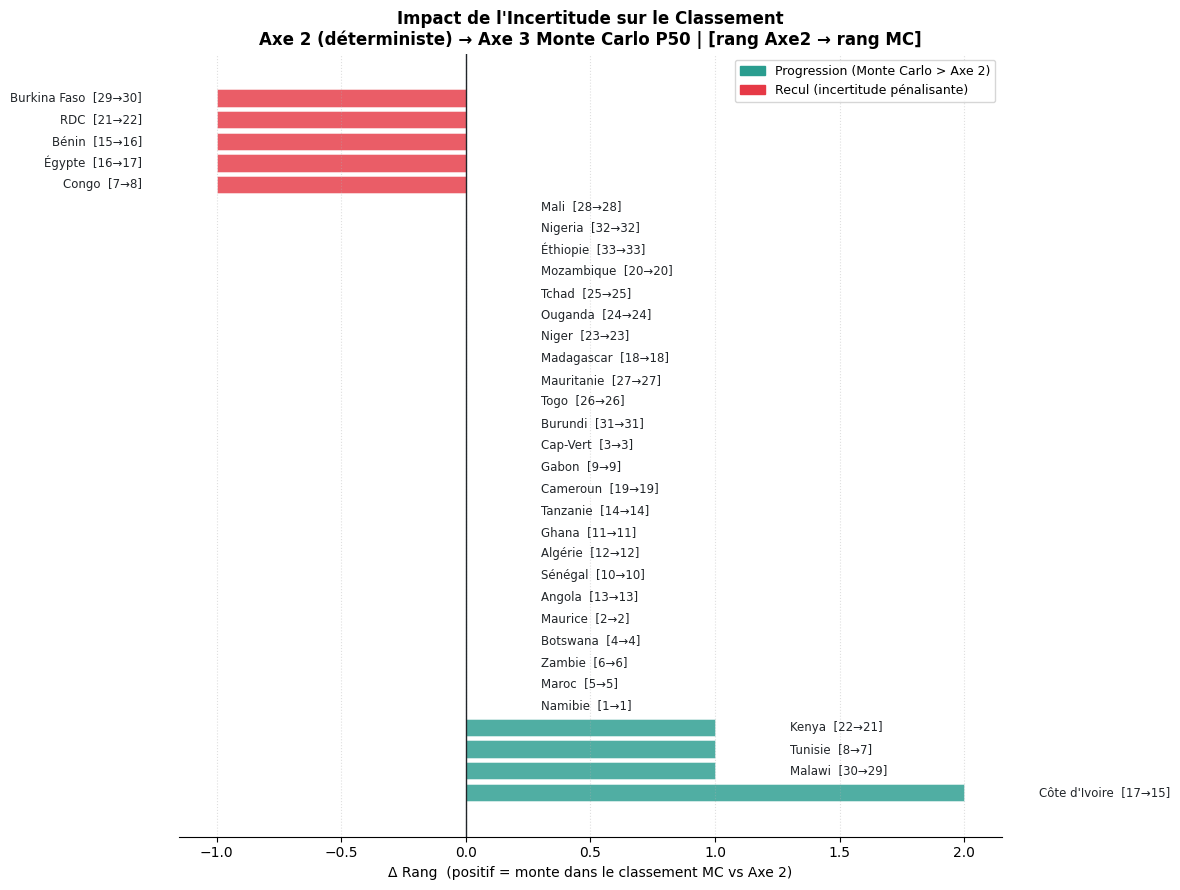

Graphique sauvegardé : mc_delta_classement_axe2_vs_axe3.png


In [16]:
# ── VIZ 6 : DELTA DE CLASSEMENT — Axe 2 vs Axe 3 ────────────────────────────
# Montre quels pays gagnent ou perdent en rang quand on intègre l'incertitude

# Reconstruction rang Axe 2
df_score1_r = df_score1.reset_index(drop=True).copy()
df_score1_r.index += 1
df_score1_r['rang_axe2'] = df_score1_r.index

df_compare = df_mc[['Pays','Region','rang_P50','score_P50',
                     'uncertainty_range','prob_top10_pct']].copy()
df_compare = df_compare.merge(
    df_score1_r[['Pays','rang_axe2','score_attractivite_100']],
    on='Pays', how='left'
)
df_compare['delta'] = df_compare['rang_axe2'] - df_compare['rang_P50']
# delta > 0 : monte en rang (s'améliore) | delta < 0 : descend en rang

df_compare = df_compare.sort_values('delta', ascending=False)

fig, ax = plt.subplots(figsize=(12, 9))

colors_delta = ['#2a9d8f' if d >= 0 else '#e63946' for d in df_compare['delta']]
bars = ax.barh(
    range(len(df_compare)), df_compare['delta'],
    color=colors_delta, alpha=0.82, edgecolor='white', linewidth=0.4
)

# Annotations pays
for idx, (_, row) in enumerate(df_compare.iterrows()):
    x_text = row['delta'] + (0.3 if row['delta'] >= 0 else -0.3)
    ha = 'left' if row['delta'] >= 0 else 'right'
    ax.text(
        x_text, idx,
        f"{row['Pays']}  [{row['rang_axe2']}→{row['rang_P50']}]",
        va='center', ha=ha, fontsize=8.5, color='#212529'
    )

ax.axvline(0, color='#212529', linewidth=1)
ax.set_yticks([])
ax.set_xlabel('Δ Rang  (positif = monte dans le classement MC vs Axe 2)', fontsize=10)
ax.set_title(
    'Impact de l\'Incertitude sur le Classement\n'
    'Axe 2 (déterministe) → Axe 3 Monte Carlo P50 | [rang Axe2 → rang MC]',
    fontsize=12, fontweight='bold'
)

green_patch = mpatches.Patch(color='#2a9d8f', label='Progression (Monte Carlo > Axe 2)')
red_patch   = mpatches.Patch(color='#e63946', label='Recul (incertitude pénalisante)')
ax.legend(handles=[green_patch, red_patch], fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('mc_delta_classement_axe2_vs_axe3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : mc_delta_classement_axe2_vs_axe3.png")

## 8. Synthèse & Interprétation Stratégique

In [17]:
# ── SYNTHÈSE FINALE ────────────────────────────────────────────────────────────

print("=" * 70)
print("    SYNTHÈSE SCORING MONTE CARLO 2030 — AtlanticRe")
print("=" * 70)

print("\n📌 TOP 5 CIBLES PRIORITAIRES (P50 élevé + faible incertitude)")
df_prioritaires = df_mc.sort_values('score_P50', ascending=False).head(5)
for _, row in df_prioritaires.iterrows():
    print(f"  {int(row['rang_P50']):2d}. {row['Pays']:<20s} "
          f"P50={row['score_P50']:.1f}  "
          f"[{row['score_P10']:.1f}–{row['score_P90']:.1f}]  "
          f"P(Top5)={row['prob_top5_pct']:.0f}%  "
          f"Borda=#{int(row['rang_borda'])}")

print("\n⚡ TOP 5 PARIS CALCULÉS (P50 élevé + forte incertitude)")
df_paris = (
    df_mc[df_mc['uncertainty_range'] > df_mc['uncertainty_range'].median()]
    .sort_values('score_P50', ascending=False)
    .head(5)
)
for _, row in df_paris.iterrows():
    print(f"  {int(row['rang_P50']):2d}. {row['Pays']:<20s} "
          f"P50={row['score_P50']:.1f}  "
          f"[{row['score_P10']:.1f}–{row['score_P90']:.1f}]  "
          f"Δ={row['uncertainty_range']:.1f}  "
          f"P(Top10)={row['prob_top10_pct']:.0f}%")

print("\n⚠️  MARCHÉS À FORT RISQUE (score P10 bas + incertitude élevée)")
df_risque = (
    df_mc[df_mc['uncertainty_range'] > df_mc['uncertainty_range'].quantile(0.75)]
    .sort_values('score_P10', ascending=True)
    .head(5)
)
for _, row in df_risque.iterrows():
    print(f"  {int(row['rang_P50']):2d}. {row['Pays']:<20s} "
          f"P10={row['score_P10']:.1f}  "
          f"P50={row['score_P50']:.1f}  "
          f"P90={row['score_P90']:.1f}  "
          f"Δ={row['uncertainty_range']:.1f}")

print("\n📊 MÉTRIQUES GLOBALES DE LA SIMULATION")
print(f"  Pays analysés      : {N_PAYS}")
print(f"  Simulations MC     : {N_SIMULATIONS:,}")
print(f"  Variables scorées  : {len(SCORE_WEIGHTS)}")
print(f"  Incertitude médiane: {df_mc['uncertainty_range'].median():.2f} pts (P90-P10)")
print(f"  Incertitude max    : {df_mc['uncertainty_range'].max():.2f} pts ({df_mc.loc[df_mc['uncertainty_range'].idxmax(), 'Pays']})")
print(f"  Pays stables (Δ<3) : {(df_mc['uncertainty_range']<3).sum()} / {N_PAYS}")
print("\n✅ Fichiers exportés :")
print(f"  - {OUTPUT_SCORING}")
print("  - mc_classement_p50_ic.png")
print("  - mc_carte_risque_opportunite.png")
print("  - mc_distributions_top10.png")
print("  - mc_proba_topN.png")
print("  - mc_matrice_dominance.png")
print("  - mc_delta_classement_axe2_vs_axe3.png")
print("\n▶ Prochaine étape : Bloc 1 (PCA/Factor Analysis) pour objectiver les poids")

    SYNTHÈSE SCORING MONTE CARLO 2030 — AtlanticRe

📌 TOP 5 CIBLES PRIORITAIRES (P50 élevé + faible incertitude)
   1. Namibie              P50=77.5  [72.3–80.8]  P(Top5)=100%  Borda=#1
   2. Maurice              P50=74.4  [69.0–80.0]  P(Top5)=100%  Borda=#2
   3. Cap-Vert             P50=58.0  [52.3–63.8]  P(Top5)=98%  Borda=#3
   4. Botswana             P50=55.0  [49.2–60.5]  P(Top5)=92%  Borda=#4
   5. Maroc                P50=50.0  [46.0–54.4]  P(Top5)=60%  Borda=#5

⚡ TOP 5 PARIS CALCULÉS (P50 élevé + forte incertitude)
   3. Cap-Vert             P50=58.0  [52.3–63.8]  Δ=11.5  P(Top10)=100%
   4. Botswana             P50=55.0  [49.2–60.5]  Δ=11.3  P(Top10)=100%
   7. Tunisie              P50=45.3  [39.3–51.1]  Δ=11.8  P(Top10)=90%
   9. Gabon                P50=42.9  [37.3–48.6]  Δ=11.3  P(Top10)=78%
  10. Sénégal              P50=40.5  [34.8–46.0]  Δ=11.2  P(Top10)=55%

⚠️  MARCHÉS À FORT RISQUE (score P10 bas + incertitude élevée)
  33. Éthiopie             P10=10.8  P50=16.4  P

## Synthèse Monte Carlo

Ce bloc simule 10 000 scénarios pour estimer la distribution des scores pays sous incertitude paramétrique. Les intervalles de confiance à 90% sont retenus comme bornes de robustesse pour le scoring final.